# Optimisation & Markov Chain Monte Carlo

## Application: Blackbody Radiation

This first block adjusts some notebook settings, you can just ignore it.

In [1]:
# Preamble

%matplotlib inline
%config InlineBackend.figure_formats = ['retina']

import matplotlib as mpl
import numpy as np

import matplotlib.pyplot as plt

import warnings

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=["olivedrab", "steelblue", "firebrick", "goldenrod"]) 
plt.rcParams['figure.figsize'] = [8,5]
plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['legend.frameon'] = False
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["ytick.minor.visible"] = True

np.random.seed(0)

## 1. The Model

Now we define the blackbody specific intensity and its gradient, together with the corresponding $\chi^2$ function and derivative, which we need for the following steps on optimisation and Markov Chain Monte Carlo (MCMC) sampling.

$$\begin{aligned}
B_\nu(T) &= \frac{2h \nu^3}{c^2} \frac{1}{e^{h\nu / kT} - 1} &
\partial_T B_\nu(T) &= \frac{2h^2 \nu^4}{c^2kT^2} \frac{e^{h\nu / kT}}{e^{h\nu / kT} - 1} \\\\
\chi^2(T, I_\nu, \nu, \sigma) &= \sum_k\frac{\left(I_{\nu,\kern+1pt k} - B_\nu(T)\right)^2}{\sigma_k^2} &
\partial_T \chi^2(T, I_\nu, \nu, \sigma) &= -2\sum_k\frac{\left(I_{\nu_k} - B_{\nu_k}(T)\right) \partial_T B_{\nu_k}(T)}{\sigma_k^2}
\end{aligned}$$

Implied with this formulation is that we assume any measurements we analyse in this notebook to be generated from an infinitely narrow line following a perfect blackbody spectrum, with no uncertainties in the frequency domain and the only errors considered being in the radiance itself.

In [2]:
# Define Model

def bb(f, T):
    '''
    Parameters:
        f : frequency [Hz]
        T : temperature [K]
    Returns:
        bb : blackbody spectral radiance [erg s⁻¹ sr⁻¹ cm⁻² Hz⁻¹]
    '''
    c = 2.99792458e10
    h = 6.62607015e-27
    k = 1.380649e-16
    return (2 * h  * f**3.0 / c**2.0) / (np.exp(h * f / (k * T)) - 1.0)

def bbGrad(f, T):
    '''
    Parameters:
        f : frequency [Hz]
        T : temperature [K]
    Returns:
        bbGrad : blackbody temperature derivative [erg s⁻¹ sr⁻¹ cm⁻² Hz⁻¹ K⁻¹]
    '''
    c = 2.99792458e10
    h = 6.62607015e-27
    k = 1.380649e-16
    return (2 * h  * f**3.0 / c**2.0) * (h * f / (k * T**2.0)) * np.exp(h * f / (k * T)) / (np.exp(h * f / (k * T)) - 1.0)**2.0

def chiSq(T, I, f, s):
    '''
    Parameters:
        T : temperature [K]
        I : specific intensity [erg s⁻¹ sr⁻¹ cm⁻² Hz⁻¹]
        f : frequency [Hz]
        s : uncertainty [erg s⁻¹ sr⁻¹ cm⁻² Hz⁻¹]
    Returns:
        chiSq : χ² likelihood metric
    '''
    return np.sum((I - bb(f, T))**2.0 / s**2.0)

def chiSqGrad(T, I, f, s):
    '''
    Parameters:
        T : temperature [K]
        I : specific intensity [erg s⁻¹ sr⁻¹ cm⁻² Hz⁻¹]
        f : frequency [Hz]
        s : uncertainty [erg s⁻¹ sr⁻¹ cm⁻² Hz⁻¹]
    Returns:
        chiSqGrad : χ² temperature derivative [K⁻¹]
    '''
    return np.sum(-2.0 * (I - bb(f, T)) * bbGrad(f, T) / s**2.0)

Here, I implemented the numerical methods we will use: Gradient Descent, Backtracking Line Search, and Metropolis MCMC. If you are interested, you are welcome to look over the functions and what they do. However, my goal with this notebook is more so for us to get a conceptual understanding of what is going on behind the formulas we see, so the exact implementation is not overly important for now.

In [3]:
# Implement Methods

def gradDesc(T, I, f, s, m = 10**5, alpha = 1e2, epsilon = 1e-16):
    '''1e2
    Parameters:
        T : initialisation temperature [K]
        I : specific intensity [erg s⁻¹ sr⁻¹ cm⁻² Hz⁻¹]
        f : frequency [Hz]
        s : uncertainty [erg s⁻¹ sr⁻¹ cm⁻² Hz⁻¹]
    Optional:
              m : maximum iteration number
          alpha : step size coefficient
        epsilon : cutoff tolerance
    Returns:
        gradDesc : iterated T values
    '''
    theta = np.array([T])
    k = 0
    while True:
        grad = chiSqGrad(theta[k], I, f, s)
        theta = np.append(theta, theta[k] - alpha * grad)
        k += 1
        if np.abs(theta[k] / theta[k - 1] - 1.0)  < epsilon:
            break
        if k >= m:
            break
    print('\n')
    print(f'initialization:   T = {T:.0f} K')
    print(f'  optimization:   T = {theta[-1]:.0f} K')
    print(f'    iterations:   k = {k}')
    print('\n')
    return [theta, k]

def gradDescLineSearch(T, I, f, s, m = 10**5, init = 1e2, tau = 0.5, kappa = 0.5, epsilon = 1e-16):
    '''
    Parameters:
        T : initialisation temperature [K]
        I : specific intensity [erg s⁻¹ sr⁻¹ cm⁻² Hz⁻¹]
        f : frequency [Hz]
        s : uncertainty [erg s⁻¹ sr⁻¹ cm⁻² Hz⁻¹]
    Optional:
              m : maximum iteration number
           init : initial step size coefficient
            tau : backtracking factor
          kappa : loop condition factor
        epsilon : cutoff tolerance
    Returns:
        gradDescLineSearch : iterated T values
    '''
    theta = np.array([T])
    alpha = np.array([init])
    k = 0
    while True:
        grad = chiSqGrad(theta[k], I, f, s)
        while chiSq(theta[-1], I, f, s) - chiSq(theta[-1] - alpha[-1] * grad, I, f, s) < kappa * alpha[-1] * grad**2.0:
            alpha[-1] *= tau
        theta = np.append(theta, theta[k] - alpha[-1] * grad)
        alpha = np.append(alpha, init)
        k += 1
        if np.abs(theta[k] - theta[k - 1]) / theta[k - 1] < epsilon:
            break
        if k >= m:
            break
    print('\n')
    print(f'initialization:   T = {T:.0f} K')
    print(f'  optimization:   T = {theta[-1]:.0f} K')
    print(f'    iterations:   k = {k}')
    print('\n')
    return [theta, k]

def metroMCMC(n, T, I, f, s, h = 6e1, m = 10**6):
    '''
    Parameters:
        n : sample size
        T : initialisation temperature [K]
        I : specific intensity [erg s⁻¹ sr⁻¹ cm⁻² Hz⁻¹]
        f : frequency [Hz]
        s : uncertainty [erg s⁻¹ sr⁻¹ cm⁻² Hz⁻¹]
    Optional:
        h : proposal distribution standard deviation [K]
        m : maximum evaluation number
    Returns:
        metroMCMC : sample chain
    '''
    theta = np.array([T])
    k = 0
    l = 0
    while n > l + 1 and k < m:
        th = np.random.normal(theta[l], h)
        r = np.exp((chiSq(theta[l], I, f, s) - chiSq(th, I, f, s)) / 2)
        if r >= 1.0:
            theta = np.append(theta, th)
            l += 1
        else:
            p = np.random.uniform(0.0, 1.0)
            if r >= p:
                theta = np.append(theta, th)
                l += 1
        k += 1
    ac = n / k
    print('\n')
    print(f'done:   generated {len(theta)} samples after {k} evaluations with acceptance ratio {100 * ac:.2f}%')
    print('\n')
    return [theta, ac]

In [4]:
# User Functions

def plotChiSq(I, f, s, lim = (0.5e3, 6.5e3), num = 200):
    '''
    Parameters:
        I : specific intensity [erg s⁻¹ sr⁻¹ cm⁻² Hz⁻¹]
        f : frequency [Hz]
        s : uncertainty [erg s⁻¹ sr⁻¹ cm⁻² Hz⁻¹]
    Optional:
        lim : plotting limits [K] , [K]
        num : step number
    Returns:
        plotChiSq : plotted T values and χ² metric
    '''
    x = np.linspace(*lim, num)
    y = np.zeros(len(x))
    for i in range(len(x)):
        y[i] = chiSq(x[i], I, f, s)
    plt.plot(x, y)
    plt.gca().ticklabel_format(axis='both', style='sci', scilimits=(0,0), useMathText=True)
    plt.xlabel(r'$T$ / K')
    plt.ylabel(r'$\chi^2$')
    plt.show()
    plt.close()
    return [x, y]

def plotGradDesc(T, I, f, s, m = 10**5, lim = (0.5e3, 6.5e3), num = 200, alpha = 1e2, epsilon = 1e-16):
    '''
    Parameters:
        T : temperature [K]
        I : specific intensity [erg s⁻¹ sr⁻¹ cm⁻² Hz⁻¹]
        f : frequency [Hz]
        s : uncertainty [erg s⁻¹ sr⁻¹ cm⁻² Hz⁻¹]
    Optional:
              m : maximum iteration number
            lim : plotting limits [K] , [K]
            num : step number
          alpha : step size coefficient
        epsilon : cutoff tolerance
    Returns:
        plotGradDesc : optimal parameters and plotted T values
    '''
    temp, k = gradDesc(T, I, f, s, m, alpha, epsilon)
    opt = temp[-1]
    step = np.zeros(k + 1)
    for i in range(k + 1):
        step[i] = chiSq(temp[i], I, f, s)
    x = np.linspace(*lim, num)
    y = np.zeros(len(x))
    for i in range(len(x)):
        y[i] = chiSq(x[i], I, f, s)
    plt.plot(x, y)
    plt.plot(temp, step, 'k', zorder=10)
    plt.scatter(temp, step, s=(30.0 / (np.arange(k + 1) + 1)), c='k', zorder=10)
    plt.gca().ticklabel_format(axis='both', style='sci', scilimits=(0,0), useMathText=True)
    plt.xlabel(r'$T$ / K')
    plt.ylabel(r'$\chi^2$')
    plt.show()
    plt.close()
    return [opt, temp, k]

def plotGradDescLineSearch(T, I, f, s, m = 10**5, lim = (0.5e3, 6.5e3), num = 200, init = 1e2, tau = 0.5, kappa = 0.5, epsilon = 1e-16):
    '''
    Parameters:
        T : temperature [K]
        I : specific intensity [erg s⁻¹ sr⁻¹ cm⁻² Hz⁻¹]
        f : frequency [Hz]
        s : uncertainty [erg s⁻¹ sr⁻¹ cm⁻² Hz⁻¹]
    Optional:
              m : maximum iteration number
            lim : plotting limits [K] , [K]
            num : step number
           init : initial step size coefficient
            tau : backtracking factor
          kappa : loop condition factor
        epsilon : cutoff tolerance
    Returns:
        plotGradDescLineSearch : optimal parameters and plotted T values
    '''
    temp, k = gradDescLineSearch(T, I, f, s, m, init, tau, kappa, epsilon)
    opt = temp[-1]
    step = np.zeros(k + 1)
    for i in range(k + 1):
        step[i] = chiSq(temp[i], I, f, s)
    x = np.linspace(*lim, num)
    y = np.zeros(len(x))
    for i in range(len(x)):
        y[i] = chiSq(x[i], I, f, s)
    plt.plot(x, y)
    plt.plot(temp, step, 'k', zorder=10)
    plt.scatter(temp, step, s=(30.0 / (np.arange(k + 1) + 1)), c='k', zorder=10)
    plt.gca().ticklabel_format(axis='both', style='sci', scilimits=(0,0), useMathText=True)
    plt.xlabel(r'$T$ / K')
    plt.ylabel(r'$\chi^2$')
    plt.show()
    plt.close()
    return [opt, temp, k]

def plotMetroMCMC(n, T, I, f, s, h = 6e1, m = 10**6, lim = (1e0, 1e15), num = 200, spread = 1e0):
    '''
    Parameters:
        n : sample size
        T : initialisation temperature [K]
        I : specific intensity [erg s⁻¹ sr⁻¹ cm⁻² Hz⁻¹]
        f : frequency [Hz]
        s : uncertainty [erg s⁻¹ sr⁻¹ cm⁻² Hz⁻¹]
    Optional:
        h : proposal distribution standard deviation [K]
        m : maximum evaluation number
        lim : plotting limits [Hz] , [Hz]
        num : step number
        spread : exaggeration factor
    Returns:
        plotMetroMCMC : plotted chain and acceptance ratio
    '''
    chain, ac = metroMCMC(n, T, I, f, s, h, m)
    plt.plot(chain, lw=0.03)
    plt.xlabel(r'$k$')
    plt.ylabel(r'$T_k$ / K')
    plt.show()
    plt.close()
    hist, edge = np.histogram(chain, bins=50)
    hist = np.array([*hist, hist[-1]])
    plt.step(edge, hist)
    plt.ylim(plt.ylim())
    lower = np.argmin(np.abs(hist[:np.argmax(hist)] - np.exp(-0.5) * np.max(hist)))
    upper = np.argmax(hist) + np.argmin(np.abs(hist[np.argmax(hist):] - np.exp(-0.5) * np.max(hist))) + 1
    print('\n')
    print(f'sampling estimate:   T = {np.mean(chain):.0f}(+{edge[upper] - np.mean(chain):.0f})(-{np.mean(chain) - edge[lower]:.0f}) K')
    print('\n')
    plt.fill_between(edge[lower:upper], -np.array(hist[lower:upper]), hist[lower:upper], step='pre', color='olivedrab', edgecolor='none', alpha=0.25)
    plt.axvline(T, ls='--', c='k', lw=1.0)
    lims = (edge[0] - 3.0 * (edge[1] - edge[0]), edge[-1] + 3.0 * (edge[-1] - edge[-2]))
    plt.xlim(lims)
    plt.gca().ticklabel_format(axis='y', style='sci', scilimits=(0,0), useMathText=True)
    plt.xlabel(r'$T$ / K')
    plt.ylabel(r'$n_T$')
    plt.show()
    plt.close()
    x = np.linspace(edge[0], edge[-1], num)
    y = np.zeros(len(x))
    for i in range(len(x)):
        y[i] = np.exp(- chiSq(x[i], I, f, s) / 2.0)
    left = np.argmin(np.abs(y[:np.argmax(y)] - np.exp(-0.5) * np.max(y)))
    right = np.argmax(y) + np.argmin(np.abs(y[np.argmax(y):] - np.exp(-0.5) * np.max(y)))
    print('\n')
    print(f'likelihood estimate:   T = {x[np.argmax(y)]:.0f}(+{x[right] - x[np.argmax(y)]:.0f})(-{x[np.argmax(y)] - x[left]:.0f}) K')
    print('\n')
    plt.plot(x, y)
    plt.ylim(plt.ylim())
    plt.fill_between(x[left:right], -y[left:right], y[left:right], color='olivedrab', edgecolor='none', alpha=0.25)
    plt.axvline(T, ls='--', c='k', lw=1.0)
    plt.gca().ticklabel_format(axis='y', style='sci', scilimits=(0,0), useMathText=True)
    plt.xlabel(r'$T$ / K')
    plt.ylabel(r'$e^{-\chi^2 / \, 2}$')
    plt.xlim(lims)
    plt.show()
    plt.close()
    print('\n')
    print(f'spread exaggeration factor:   {spread:.2f}')
    print('\n')
    freq = np.linspace(*lim, num)
    rad = bb(freq, T)
    plt.errorbar(f, I, yerr=s, fmt='.', c='lightgray', ms=4.32, zorder=-1)
    samp = chain[::int(n / 1000)]
    for el in samp:
        plt.plot(freq, bb(freq, T) - spread * (bb(freq, T) - bb(freq, el)), c='olivedrab', lw=0.03, alpha=0.3, zorder=100)
    plt.plot(freq, rad)
    plt.gca().ticklabel_format(axis='both', style='sci', scilimits=(0,0), useMathText=True)
    plt.xlabel(r'$\nu$ / Hz')
    plt.ylabel(r'$B_\nu$ / erg s$^{-1}$ sr$^{−1}$ cm$^{−2}$ Hz$^{−1}$')
    plt.show()
    plt.close()
    return [chain, ac]

def plotRadDistrib(freq, chain):
    '''
    Parameters:
         freq : frequency [Hz]
        chain : MCMC samples [T]
    Returns:
        plotRadDistrib : first raw and second centered moment estimates of the distribution
    '''
    dist = bb(freq, chain)
    hist, edge = np.histogram(dist, bins=50)
    hist = [*hist, hist[-1]]
    plt.step(edge, hist)
    lower = np.argmin(np.abs(hist[:np.argmax(hist)] - np.max(hist) * np.exp(-1/2)))
    upper = np.argmax(hist) + np.argmin(np.abs(hist[np.argmax(hist):] - np.max(hist) * np.exp(-1/2))) + 1
    mean = np.sum(hist * edge) / np.sum(hist)
    est = edge[np.argmax(hist)]
    mag = int(np.log10(est)) - 2
    print('\n')
    print(f'I = {est / 10.0**mag:.2f}(+{(edge[upper] - est) / 10.0**mag:.2f})(-{(est - edge[lower]) / 10.0**mag:.2f})e{mag:.0f} ergs⁻¹sr⁻¹cm⁻²Hz⁻¹')
    print('\n')
    var = np.sum(hist * (edge - mean)**2.0) / np.sum(hist)
    std = np.sqrt(var)
    plt.ylim(plt.ylim())
    plt.fill_between(edge[lower:upper], -np.array(hist[lower:upper]), hist[lower:upper], step='pre', color='olivedrab', edgecolor='none', alpha=0.25)
    plt.xlabel(r'$I_\nu$ / erg s$^{-1}$ sr$^{−1}$ cm$^{−2}$ Hz$^{−1}$')
    plt.ylabel(r'$n_{I_\nu}$')
    plt.plot([], [], ' ', label=f'$\\nu = {10.0**(np.log10(freq) - int(np.log10(freq))):.0f} \\cdot 10^{{{int(np.log10(freq)):.0f}}}$ Hz')
    plt.axvline(mean, ls='-', c='k', lw=1.0, label='Expectation Value')
    plt.axvline(mean + std, ls='--', c='k', lw=1.0, label='Standard Deviation')
    plt.axvline(mean - std, ls='--', c='k', lw=1.0)
    plt.legend(loc='upper right')
    plt.gca().ticklabel_format(axis='x', style='sci', scilimits=(0,0), useMathText=True)
    plt.show()
    plt.close()
    return [mean, std]

## 2. The Data

For the first dataset, its shape can roughly be interpreted as that of a stellar spectrum we might have measured. In contrast to this, the second one does not follow any obvious distribution and was simply chosen to demonstrate the trouble with multimodal distributions for both MCMC methods and optimisers.

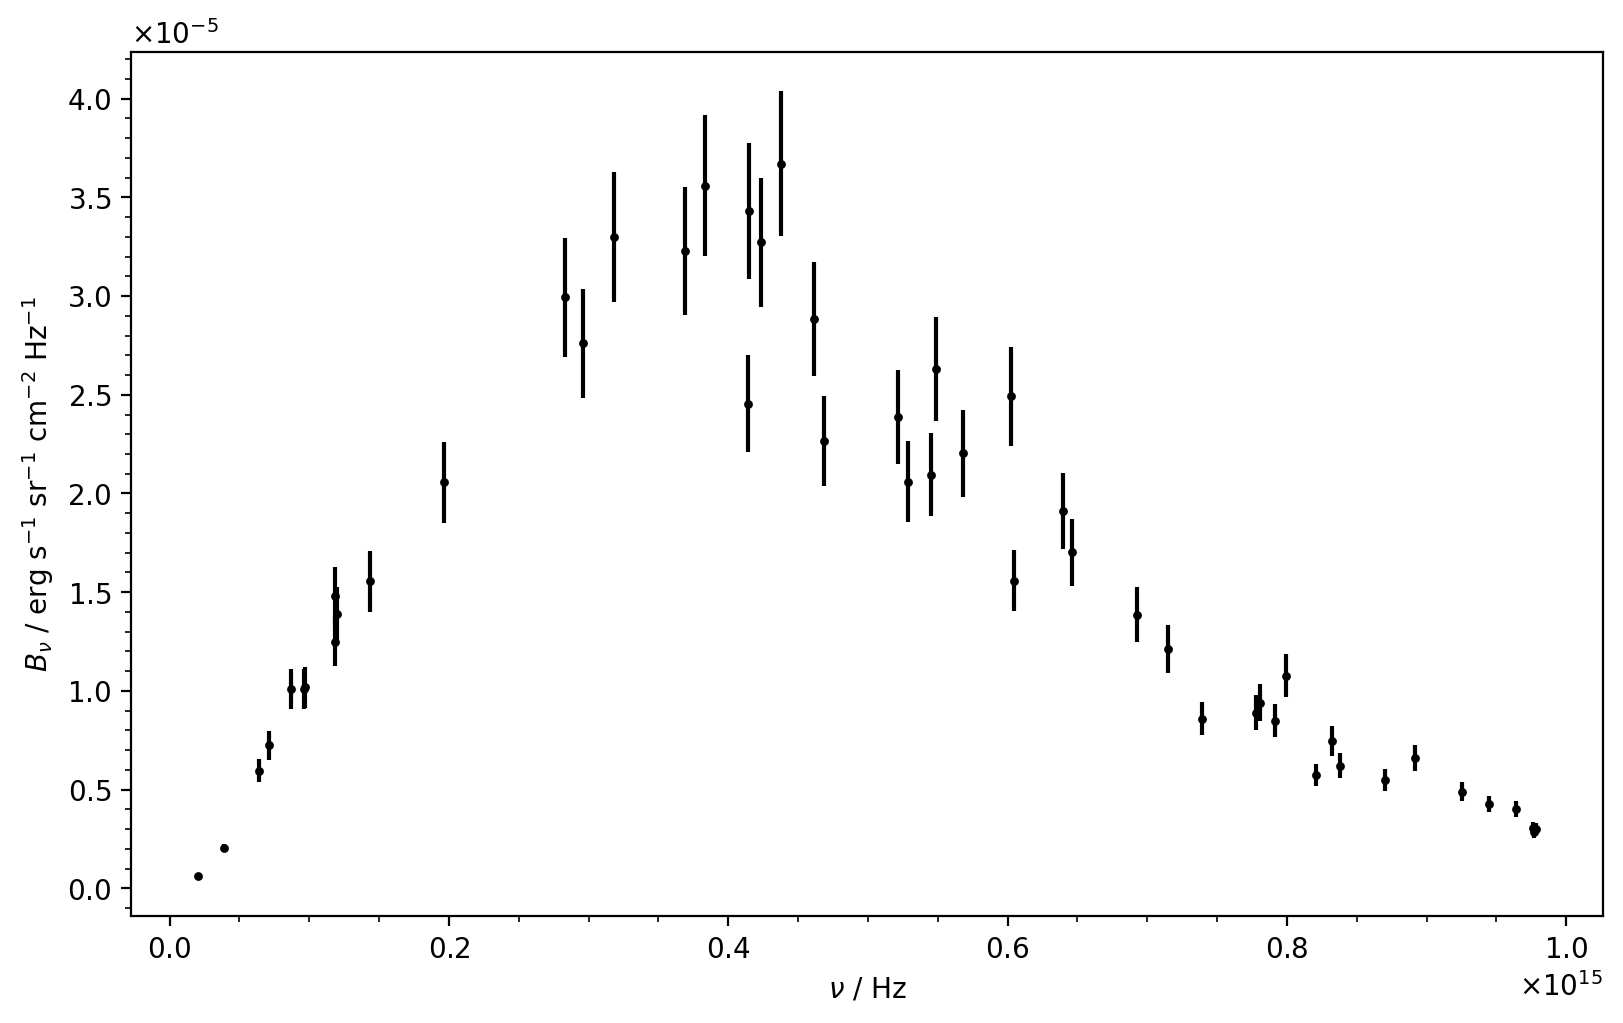

In [5]:
# Generated Data

f1 = np.array([5.48813504e+14, 7.15189366e+14, 6.02763376e+14, 5.44883183e+14, 4.23654799e+14,
               6.45894113e+14, 4.37587211e+14, 8.91773001e+14, 9.63662761e+14, 3.83441519e+14,
               7.91725038e+14, 5.28894920e+14, 5.68044561e+14, 9.25596638e+14, 7.10360582e+13,
               8.71292997e+13, 2.02183974e+13, 8.32619846e+14, 7.78156751e+14, 8.70012148e+14,
               9.78618342e+14, 7.99158564e+14, 4.61479362e+14, 7.80529176e+14, 1.18274426e+14,
               6.39921021e+14, 1.43353287e+14, 9.44668917e+14, 5.21848322e+14, 4.14661940e+14,
               1.96582362e+14, 3.68725171e+14, 8.20993230e+14, 9.71012758e+13, 8.37944907e+14,
               9.60984079e+13, 9.76459465e+14, 4.68651202e+14, 9.76761088e+14, 6.04845520e+14,
               7.39263579e+14, 3.91877923e+13, 2.82806963e+14, 1.20196561e+14, 2.96140198e+14,
               1.18727719e+14, 3.17983179e+14, 4.14262995e+14, 6.41474963e+13, 6.92472119e+14])

I1 = np.array([2.63274811e-05, 1.21417660e-05, 2.49204263e-05, 2.09555632e-05, 3.27303867e-05,
               1.70220577e-05, 3.67045038e-05, 6.58100397e-06, 4.01291351e-06, 3.55885992e-05, 
               8.50142287e-06, 2.06058904e-05, 2.20257234e-05, 4.90064291e-06, 7.25044505e-06, 
               1.00922946e-05, 6.31239825e-07, 7.45511934e-06, 8.89038218e-06, 5.49125878e-06, 
               3.02617656e-06, 1.07702106e-05, 2.88357774e-05, 9.39401658e-06, 1.25012930e-05, 
               1.91236350e-05, 1.55445087e-05, 4.27546233e-06, 2.38628443e-05, 3.43066305e-05, 
               2.05662962e-05, 3.22723430e-05, 5.74710972e-06, 1.01772974e-05, 6.21814221e-06, 
               1.00947318e-05, 3.04899283e-06, 2.26613312e-05, 2.84239756e-06, 1.55906424e-05,
               8.60284635e-06, 2.05056269e-06, 2.99304961e-05, 1.38859548e-05, 2.76157589e-05, 
               1.47972530e-05, 3.30034973e-05, 2.45467407e-05, 5.95999803e-06, 1.38702102e-05])

u1 = np.array([2.63274811e-06, 1.21417660e-06, 2.49204263e-06, 2.09555632e-06, 3.27303867e-06,
               1.70220577e-06, 3.67045038e-06, 6.58100397e-07, 4.01291351e-07, 3.55885992e-06, 
               8.50142287e-07, 2.06058904e-06, 2.20257234e-06, 4.90064291e-07, 7.25044505e-07, 
               1.00922946e-06, 6.31239825e-08, 7.45511934e-07, 8.89038218e-07, 5.49125878e-07, 
               3.02617656e-07, 1.07702106e-06, 2.88357774e-06, 9.39401658e-07, 1.25012930e-06, 
               1.91236350e-06, 1.55445087e-06, 4.27546233e-07, 2.38628443e-06, 3.43066305e-06, 
               2.05662962e-06, 3.22723430e-06, 5.74710972e-07, 1.01772974e-06, 6.21814221e-07, 
               1.00947318e-06, 3.04899283e-07, 2.26613312e-06, 2.84239756e-07, 1.55906424e-06, 
               8.60284635e-07, 2.05056269e-07, 2.99304961e-06, 1.38859548e-06, 2.76157589e-06,
               1.47972530e-06, 3.30034973e-06, 2.45467407e-06, 5.95999803e-07, 1.38702102e-06])

plt.errorbar(f1, I1, yerr=u1, fmt='k.', ms=4.32)

plt.gca().ticklabel_format(axis='both', style='sci', scilimits=(0,0), useMathText=True)

plt.xlabel(r'$\nu$ / Hz')
plt.ylabel(r'$B_\nu$ / erg s$^{-1}$ sr$^{−1}$ cm$^{−2}$ Hz$^{−1}$')

plt.show()
plt.close()

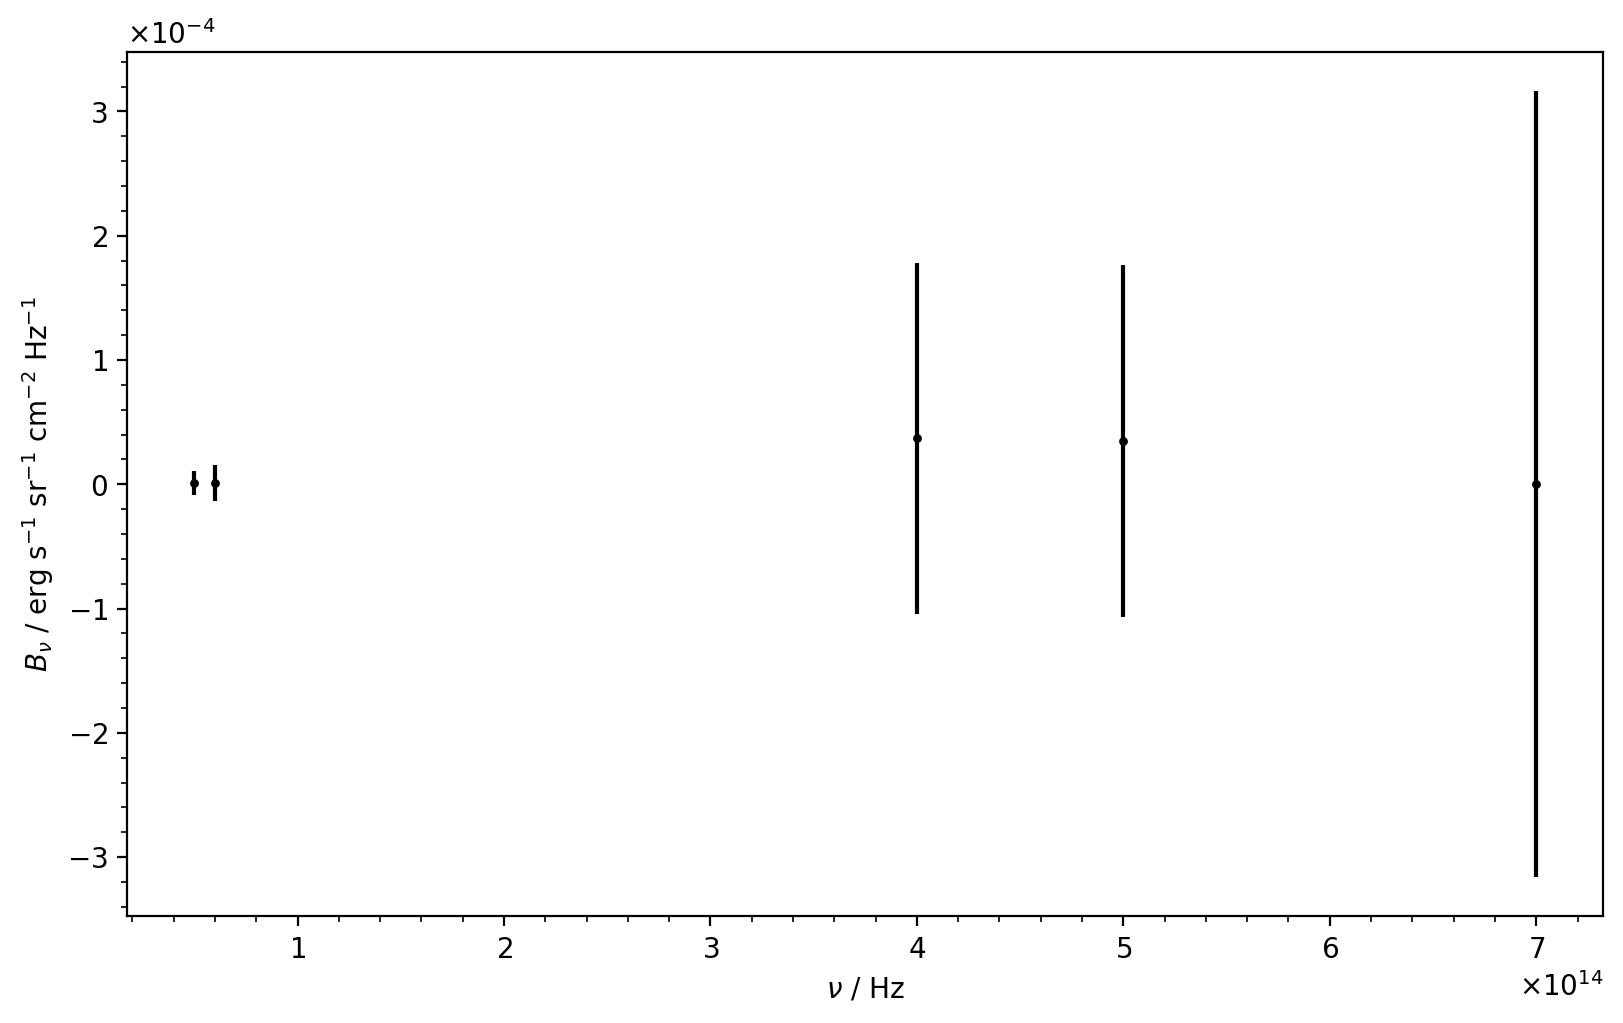

In [6]:
# Alternative Data

f2 = np.array([5e13, 5e14, 6e13, 4e14, 7e14])

I2 = np.array([1e-6, 35e-6, 1e-6, 37e-6, 1e-7])

u2 = np.sqrt(np.array([1e-10, 2e-8, 2e-10, 2e-8, 1e-7]))

plt.errorbar(f2, I2, yerr=u2, fmt='k.', ms=4.32)

plt.gca().ticklabel_format(axis='both', style='sci', scilimits=(0,0), useMathText=True)

plt.xlabel(r'$\nu$ / Hz')
plt.ylabel(r'$B_\nu$ / erg s$^{-1}$ sr$^{−1}$ cm$^{−2}$ Hz$^{−1}$')

plt.show()
plt.close()

data2 = np.stack([f2, I2, u2], axis=0)

## 3. Exploration

From here onwards I would like you to experiment with the methods shown, play with the parameters and see what errors or edge cases you may find. Included in the cells are some suggestions, but you are welcome to make your own choices.

### 3.1. The Logarithmic Likelihood

Since this is the same as the $\chi^2$ metric except for constant terms and factors under our assumptions, we will simply plot what we already implemented. You should recognise that for our first dataset, the plot looks to be convex and therefore well behaved for optimisation, in the sense that if we find a minimum, it is guaranteed to be the global one. Things get trickier for the second case, which is no surprise since we have very little data with massive uncertainties. The function has a long flat tail and a local minimum which is different from the global one. We will see how this affects our results.

In [ ]:
# Logarithmic Likelihood

T1, chiSq1 = plotChiSq(I1, f1, u1)
T2, chiSq2 = plotChiSq(I2, f2, u2)

### 3.2. Gradient Descent with Fixed Stepsize

To minimise the $\chi^2$ metric, we now use a simple gradient descent optimiser with a fixed stepsize coefficient. We can vary this setting as well as the starting point for both of our datasets to see what changes. Things to look out for are very slow convergence, overshoots and oscillating configurations that never converge, as well as false minima. Think about what conditions cause which failure mode. As a reminder, the gradient descent algorithm looks something like this:

- Starting from our initial guess $T_0$ for the temperature, we use the gradient to iteratively update the parameter.$\vphantom{\big|_{T_k}}$
- To do this, we set $T_{k + 1} = T_k - \alpha\partial_T\chi^2\big|_{T_k}$ using the previously defined gradient to move in direction of decreasing $\chi^2$ values and multiplying with a factor $\alpha$ to set the magnitude of each step.$\vphantom{\big|_{T_k}}$
- We repeat this iteration until a convergence criterion $\left| \frac{T_{k + 1}}{T_k} - 1 \right| < \epsilon$ with cutoff $\epsilon$ is fulfilled or our previously set maximum step count has been reached.$\vphantom{\big|_{T_k}}$

In [ ]:
# Good Likelihood: Different Convergence Paths

opt1, temp1, k1 = plotGradDesc(6.3e3, I1, f1, u1, alpha = 1e2)
opt2, temp2, k2 = plotGradDesc(6.3e3, I1, f1, u1, alpha = 1e1)
opt3, temp3, k3 = plotGradDesc(1.5e3, I1, f1, u1, alpha = 1e2)

In [ ]:
# Good Likelihood: Increase & Oscillation

opt4, temp4, k4 = plotGradDesc(6.0e3, I1, f1, u1, alpha = 3e2)

In [ ]:
# Bad Likelihood: Slow Convergence

opt5, temp5, k5 = plotGradDesc(6.3e3, I2, f2, u2, alpha = 1e2)
opt6, temp6, k6 = plotGradDesc(6.3e3, I2, f2, u2, alpha = 1e4)

In [ ]:
# Bad Likelihood: Local Optima

opt7, temp7, k7 = plotGradDesc(3.3e3, I2, f2, u2, alpha = 1e7)
opt8, temp8, k8 = plotGradDesc(2.9e3, I2, f2, u2, alpha = 1e8)

### 3.3. Gradient Descent with Backtracking Linesearch

To improve upon the previous gradient descent algorithm, a line search can be performed at each step to adapt the $\alpha \equiv \alpha_k$ coefficient, allowing the optimisation to move along the function faster and therefore converge more efficiently. Probably the easiest implementation of this is a backtracking line search that starts from a large fixed value at any $k$ and then iteratively reduces it until some condition that ensures $\chi^2$ descreases is satisfied. This also has the effect of increasing the relative step size for very flat gradients, thereby avoiding saddle points. The nested algorithm that is executed before taking each step in the previous descriptions is defined as follows:

- Starting from an initial large $\alpha^0$ factor, we iterate.$\vphantom{\big|_{T_k}}$
- As long as $\chi^2\big|_{T_k} - \chi^2\big|_{T_k - \alpha^j \partial_T\chi^2\big|_{T_k}} < \kappa\alpha^j \bigl(\partial_T\chi^2\big|_{T_k}\bigr)^2$ we set $\alpha^{j+1} = \tau\alpha^j$ where $\kappa\,,\tau \in [0,1]$ is required.
- Once this is no longer fulfilled, we choose $\alpha_k = \alpha^j$ to make the next step down the slope and repeat.$\vphantom{\big|_{T_k}}$

In [ ]:
# Good Likelihood: Guaranteed Convergence

opt9, temp9, k9 = plotGradDescLineSearch(6.4e3, I1, f1, u1, init = 1e2)
opt10, temp10, k10 = plotGradDescLineSearch(1.1e3, I1, f1, u1, init = 1e3)

In [ ]:
# Bad Likelihood: Local Optima

opt11, temp11, k11 = plotGradDescLineSearch(6.3e3, I2, f2, u2, init = 1e8)
opt12, temp12, k12 = plotGradDescLineSearch(0.9e3, I2, f2, u2, init = 1e8)

For a good summary of other optimisation methods mentioned in the presentation, check out [this](https://andycasey.github.io/teaching/phs5000/4/) chapter by Andy Casey. It also includes some nice interactive visualisations made by Ben Frederickson.

### 3.4. Metropolis MCMC

Next up, we use the Metropolis MCMC algorithm to explore the target distribution. As a shortcut, it is a good idea to choose one of the previously obtained optimisation results for our initial guess. You should still try different parameters to test burn in and autocorrelation behaviour. Here is the pseudocode that is implemented in one of the above methods, we will discuss why it looks like it does:

- Start from $T_0$ as our initialisation.$\vphantom{\big|_{T_k}}$
- Draw a temperature value $\hat{T}_{k+1}$ from a Gaussian distribution $\mathcal{N}(T_k, h)$ centered at the current position $T_k$ with variance $h^2$ as a proposal for the next step.$\vphantom{\big|_{T_k}}$
- Calculate the probability ratio $r = e^{-\chi^2/2}\big|_{\hat{T}_{k+1}} \bigl( e^{-\chi^2/2}\big|_{T_k} \bigr)^{-1}$ between the current and proposed position.
- Draw a number $p \in [0,1]$ from a uniform distribution $\mathcal{U}(0,1)$ and move to the new position $T_{k+1} = \hat{T}_{k+1}$ only if $r > p$ is fulfilled, otherwise discard $\hat{T}_{k+1}$ and repeat until the maximum desired number of samples have been generated or evaulations have been performed.

In [ ]:
# Good Likelihood: Trace, Histogram, Posterior, Lines

chain1, ac1 = plotMetroMCMC(50000, opt10, I1, f1, u1, spread = 1e1)

In [ ]:
# Bad Likelihood: True & False Optima

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    chain2, ac2 = plotMetroMCMC(50000, opt11, I2, f2, u2, h = 1e4)
    chain3, ac3 = plotMetroMCMC(50000, opt12, I2, f2, u2, h = 1e4)

For a more detailed overview of different MCMC samplers by Andy Casey, click [here](https://andycasey.github.io/teaching/phs5000/5/) to visit the website.

### 3.5. Propagating Errors

Finally, as an example of the useful application of MCMC sampling, the following shows the distribution of the blackbody intensity for a specific frequency. We obtain this simply by drawing some values from our temperature samples, and since their numbers are proportional to the underlying likelihood, we get a distribution of values instead of a point estimate, which we can use to calculate confidence bands or asymmetric uncertainty intervals if we want to use our model function to predict future measurements and perform consistency checks for the same source.

In [ ]:
# Good Likelihood: Uncertainty Estimates

mean1, std1 = plotRadDistrib(7e13, chain1)
mean2, std2 = plotRadDistrib(3e14, chain1)
mean3, std3 = plotRadDistrib(9e14, chain1)

*This notebook can be found [here](https://github.com/fritzali/notes/blob/main/MASS/Numerical/talk/answer.ipynb) together with more materials for the discussed topics.*